In [1]:
from bmc.lake import wekeo
import yaml

In [2]:
%load_ext snakeviz

In [3]:
lake_recipe = """
paths:
  base_dir: "./microlake"
  raw_dir: "./microlake/raw/"

lake_name: "micro_lake_1km"

raw_config:
  keep_raw: false
  spatial:
    use_bbox: true

spatial:
  target_grid_key: "EEA_1km"
  resampling_strategies:
    continuous: ["average", "max", "min", "rms"]
    discrete: "coverage" 
  bbox:
      long_min: 3.866685
      long_max: 4.945801
      lat_min: 50.663390
      lat_max: 51.481383
temporal:
  start_year: 2017
  start_month: 1
  end_year: 2018
  end_month: 12

sources:
  wekeo:
    enabled: true
    datasets:
      TCF:
        include: true
        productTypes:
          - "Dominant Leaf Type"
          - "Tree Cover Density"
"""

recipe = yaml.safe_load(lake_recipe)
lake_dir = recipe["paths"]["base_dir"]

# 1. Initialize your engine
lake_engine = wekeo.wekeo_lake()

# 2. AUTOMATIC INITIALIZATION: Explicitly pass logger=None. 
# Your code will sense this, automatically configure the file-handler logs, 
# and tie the output path directly inside "/storage/niels/bmc/logs/micro_lake_generation.log"
%snakeviz generated_cogs = lake_engine.build_datalake(recipe, logger=None)

# 3. EXTRACTION: Now capture the automatically constructed logger from the engine instance
auto_logger = lake_engine.logger

# 4. ORCHESTRATION: Pass the captured logger to downstream steps so everything writes to the same log file
is_valid = lake_engine.validate_datalake(lake_dir, logger=auto_logger)

if is_valid:
    lake_engine.generate_catalog(lake_dir, logger=auto_logger)
else:
    if auto_logger:
        auto_logger.error("Datalake QA validation failed! Catalog creation aborted.")


                                                    2026-06-29 12:52:58,573 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:56235'.


 
*** Profile stats marshalled to file 'C:\\Users\\niels\\AppData\\Local\\Temp\\tmplyuii102'.
Embedding SnakeViz in this document...
<function display at 0x00000259AEE960C0>


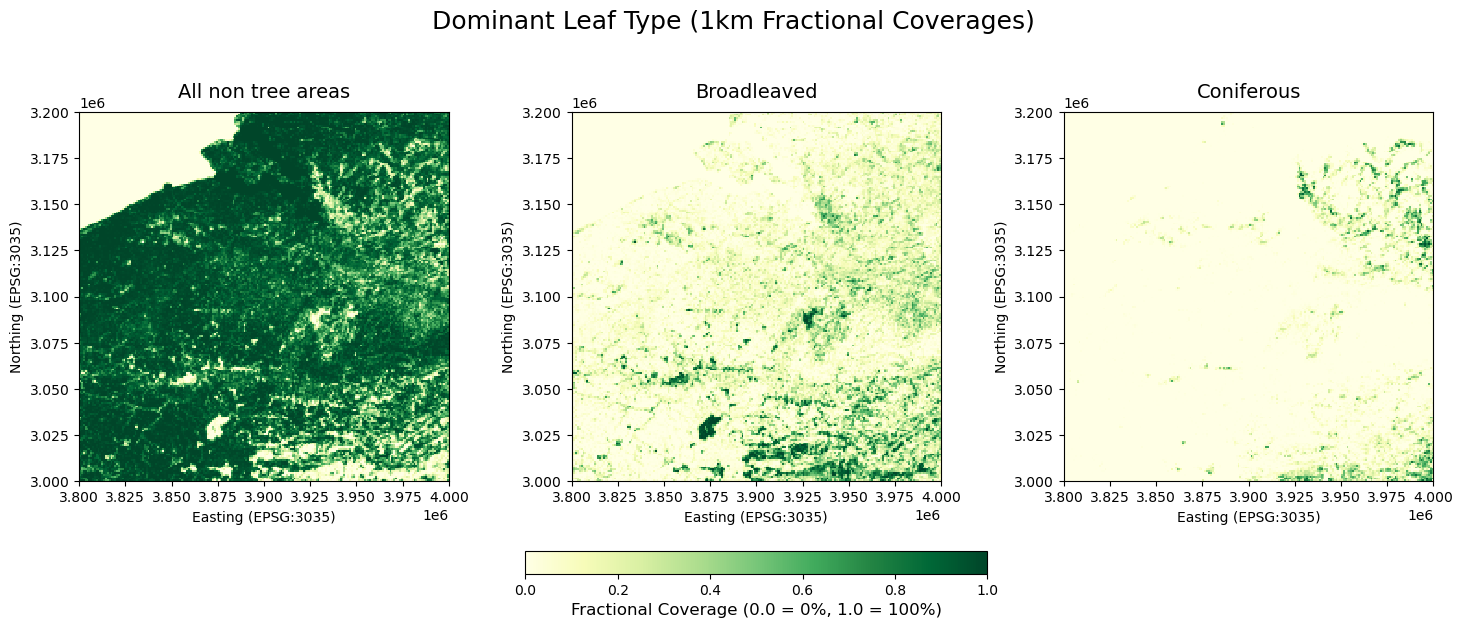

In [4]:
import os
import glob
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt

# 1. Define the directory where your COGs were baked
cog_dir = r"./microlake/TCF/Dominant_Leaf_Type/coverage"

# Find all the generated .tif files
tif_files = glob.glob(os.path.join(cog_dir, "*.tif"))

if not tif_files:
    print(f"No .tif files found in {cog_dir}! Please check the path.")
else:
    # 2. Set up a dynamic matplotlib figure based on the number of classes
    fig, axes = plt.subplots(1, len(tif_files), figsize=(6 * len(tif_files), 6))
    
    # Ensure axes is iterable even if there's only 1 file
    if len(tif_files) == 1:
        axes = [axes]

    # 3. Loop through and plot each class
    for ax, tif_path in zip(axes, tif_files):
        # Extract a clean title from the filename (e.g., 'Broadleaved')
        class_name = os.path.basename(tif_path).split('_1km_')[-1].replace('.tif', '')
        
        # Open the raster safely using a context manager
        with rioxarray.open_rasterio(tif_path, masked=True) as ds:
            # Squeeze out the 'band' dimension to make it a standard 2D array
            da = ds.squeeze()
            
            # Plot the data
            # vmin=0 and vmax=1 force the color scale to rigidly represent 0% to 100% coverage
            img = da.plot(
                ax=ax, 
                cmap="YlGn",     # Yellow to Green colormap (great for vegetation)
                vmin=0, 
                vmax=1, 
                add_colorbar=False
            )
            
            # Format the subplot
            ax.set_title(f"{class_name.replace('_', ' ')}", fontsize=14, pad=10)
            ax.set_xlabel("Easting (EPSG:3035)")
            ax.set_ylabel("Northing (EPSG:3035)")
            ax.set_aspect('equal') # Keep projection proportions accurate

    # 4. Add a single shared colorbar for the whole figure
    cbar = fig.colorbar(img, ax=axes, orientation='horizontal', fraction=0.05, pad=0.15)
    cbar.set_label("Fractional Coverage (0.0 = 0%, 1.0 = 100%)", fontsize=12)
    
    plt.suptitle("Dominant Leaf Type (1km Fractional Coverages)", fontsize=18, y=1.05)
    plt.show()

In [ ]:
%%time

lake_recipe = """
paths:
  base_dir: "./microlake_2"
  raw_dir: "./microlake_2/raw/"

lake_name: "micro_lake_1km"

raw_config:
  keep_raw: false
  spatial:
    use_bbox: true

spatial:
  target_grid_key: "EEA_1km"
  resampling_strategies:
    continuous: ["average", "max", "min", "rms"]
    discrete: "coverage" 
  bbox:
      long_min: 2.633851
      long_max: 9.377641
      lat_min: 47.264320
      lat_max: 51.412912

temporal:
  start_year: 2017
  start_month: 1
  end_year: 2018
  end_month: 12

sources:
  wekeo:
    enabled: true
    datasets:
      TCF:
        include: true
        productTypes:
          - "Dominant Leaf Type"
"""

recipe = yaml.safe_load(lake_recipe)
lake_dir = recipe["paths"]["base_dir"]

# 1. Initialize your engine
lake_engine = wekeo.wekeo_lake()

# 2. AUTOMATIC INITIALIZATION: Explicitly pass logger=None. 
# Your code will sense this, automatically configure the file-handler logs, 
# and tie the output path directly inside "/storage/niels/bmc/logs/micro_lake_generation.log"
generated_cogs = lake_engine.build_datalake(recipe, logger=None)

# 3. EXTRACTION: Now capture the automatically constructed logger from the engine instance
auto_logger = lake_engine.logger

# 4. ORCHESTRATION: Pass the captured logger to downstream steps so everything writes to the same log file
is_valid = lake_engine.validate_datalake(lake_dir, logger=auto_logger)

if is_valid:
    lake_engine.generate_catalog(lake_dir, logger=auto_logger)
else:
    if auto_logger:
        auto_logger.error("Datalake QA validation failed! Catalog creation aborted.")


c:\Users\niels\anaconda3\envs\BmC\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 56170 instead
  warnings.warn(
c:\Users\niels\anaconda3\envs\BmC\Lib\contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.49s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)
                                                    

KeyboardInterrupt: 